# Задача сегментации с использованием U-Net

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
import glob
import tensorflow as tf
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.layers import Flatten, Dense, Reshape
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import img_to_array, load_img

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!nvidia-smi

Tue Oct 14 04:46:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Simple test
with tf.device('/GPU:0'):
    a = tf.random.normal([1000, 1000])
    b = tf.random.normal([1000, 1000])
    c = tf.matmul(a, b)
print("Computation done on GPU ✅")


Computation done on GPU ✅


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vpapenko/nails-segmentation")

print("Path to dataset files:", path)

100%|██████████| 26.2M/26.2M [00:00<00:00, 163MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vpapenko/nails-segmentation/versions/1


## Функции для отображения результатов

In [6]:
def plot_image_and_mask(images, masks, image_paths):
    plt.figure(figsize=(20, 6))

    for i in range(5):
        idx = np.random.randint(len(images))
        plt.subplot(3, 8, i + 1)
        plt.imshow(images[idx], cmap="gray")
        plt.axis("off")
        plt.title(image_paths[idx].split("/")[-1])

        plt.subplot(3, 8, i + 9)
        plt.imshow(masks[idx], cmap="gray")
        plt.axis("off")
        plt.title("Mask")

    plt.show()


In [7]:
def plot_predictions(X_test, y_test, preds):
    plt.figure(figsize=(20, 6))

    for i in range(6):
        idx = np.random.randint(len(preds))
        plt.subplot(3, 8, i + 1)
        plt.imshow(X_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Image")

        plt.subplot(3, 8, i + 9)
        plt.imshow(y_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Original Mask")

        plt.subplot(3, 8, i + 17)
        plt.imshow(preds[idx], cmap="gray")
        plt.axis("off")
        plt.title("Predicted Mask")

    plt.show()

In [8]:
def plot_training_history(history, title="Training History"):
    metrics = [m for m in history.history.keys() if not m.startswith('val_')]
    n_metrics = len(metrics)

    n_cols = 2
    n_rows = (n_metrics + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16)

    for i, metric in enumerate(metrics):
        ax = axes[i]
        ax.plot(history.history[metric], label=f"train {metric}")

        val_metric = f"val_{metric}"
        if val_metric in history.history:
            ax.plot(history.history[val_metric], label=f"val {metric}")

        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f"Training vs Validation {metric.capitalize()}")
        ax.legend()
        ax.grid(True)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Подготовка данных

In [9]:
folders = os.listdir(path)
folders

['labels', 'images', 'nails_segmentation']

In [10]:
image_paths = glob.glob(path+'/images/*')
mask_paths = glob.glob(path+'/labels/*')

In [11]:
def load_image(path, color_mode=None):
    img = None
    if color_mode:
        img = load_img(path, target_size=(128, 128), color_mode=color_mode)
    else:
        img = load_img(path, target_size=(128, 128))

    image_array = img_to_array(img)
    image_array /= 255.
    return image_array

In [12]:
images = []
masks = []

for image_path, mask_path in tqdm(zip(image_paths, mask_paths)):
    image = load_image(image_path)
    images.append(image)

    mask = load_image(mask_path, color_mode='grayscale')
    masks.append(mask)

52it [00:01, 47.04it/s]


In [13]:
images = np.array(images)
masks = np.array(masks)

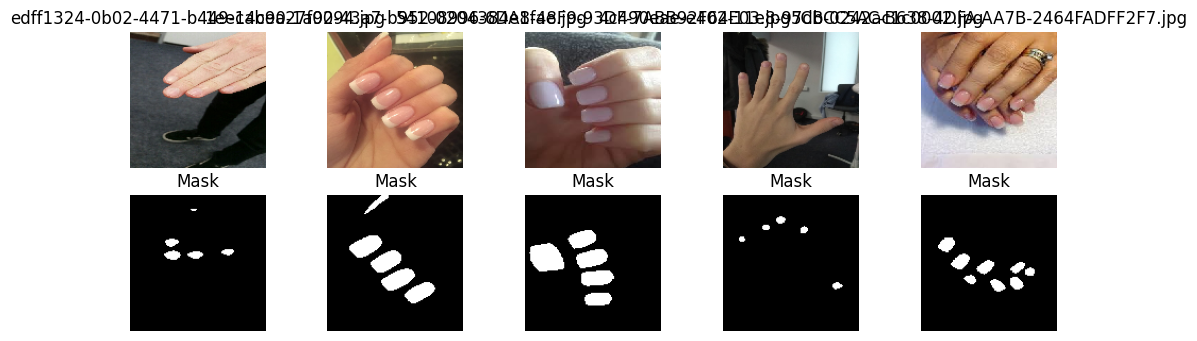

In [14]:
plot_image_and_mask(images, masks, image_paths)

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train set: {X_train.shape}, {y_train.shape}")

Train set: (41, 128, 128, 3), (41, 128, 128, 1)


## Baseline - Полносвязанная нейронная сеть

In [38]:
input_shape = (128, 128, 3)
output_shape = (128, 128, 1)

sequential_model = Sequential([
    Flatten(input_shape=input_shape),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(np.prod(output_shape), activation='sigmoid'),
    Reshape(output_shape)
])

sequential_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)
# sequential_model.summary()

In [39]:
sequential_history = sequential_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=600)

Epoch 1/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5131 - loss: 0.6877 - precision_3: 0.0572 - recall_3: 0.4970 - val_accuracy: 0.7639 - val_loss: 0.5133 - val_precision_3: 0.0294 - val_recall_3: 0.2314
Epoch 2/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7633 - loss: 0.5328 - precision_3: 0.0606 - recall_3: 0.2216 - val_accuracy: 0.9311 - val_loss: 0.2374 - val_precision_3: 0.0316 - val_recall_3: 0.0492
Epoch 3/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9103 - loss: 0.2915 - precision_3: 0.0601 - recall_3: 0.0426 - val_accuracy: 0.9702 - val_loss: 0.1514 - val_precision_3: 0.0694 - val_recall_3: 0.0052
Epoch 4/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9436 - loss: 0.2278 - precision_3: 0.1112 - recall_3: 0.0041 - val_accuracy: 0.9699 - val_loss: 0.1566 - val_precision_3: 0.1342 - val_recall_3: 0.0135
Epoch 5/600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9433 - loss: 0.2082 - precision_3: 0.2140 - recall_3: 0.0103 - val_accurac

## Реализация U-Net

In [40]:
def conv_block(inputs, num_filters):
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(x)
    return x


In [41]:
def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p


In [42]:
def decoder_block(inputs, skip_features, num_filters):
    x = layers.Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(inputs)
    x = layers.concatenate([x, skip_features])
    x = conv_block(x, num_filters)
    return x

In [43]:
def build_unet(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # --- Encoder ---
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # --- Bottleneck ---
    b1 = conv_block(p4, 1024)

    # --- Decoder ---
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # --- Output ---
    outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(d4)

    model = models.Model(inputs, outputs, name="U-Net")

    return model

In [44]:
unet_model = build_unet(input_shape=(128, 128, 3), num_classes=1)
unet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)
# unet_model.summary()

In [55]:
unet_history = unet_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=450)

Epoch 1/450
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.9466 - loss: 0.1707 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00 - val_accuracy: 0.9720 - val_loss: 0.1172 - val_precision_4: 0.0000e+00 - val_recall_4: 0.0000e+00
Epoch 2/450
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - accuracy: 0.9456 - loss: 0.1738 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00 - val_accuracy: 0.9720 - val_loss: 0.1163 - val_precision_4: 0.0000e+00 - val_recall_4: 0.0000e+00
Epoch 3/450
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.9445 - loss: 0.1741 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00 - val_accuracy: 0.9720 - val_loss: 0.1167 - val_precision_4: 0.0000e+00 - val_recall_4: 0.0000e+00
Epoch 4/450
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.9457 - loss: 0.1724 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00 - val_accuracy: 0.9720 - val_loss: 0.1146 - val_precision_4: 0.0000e+00 - val_recall_4: 0.0000e+00
Epoch 5/450
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.945

## Сравнение результатов

### Baseline

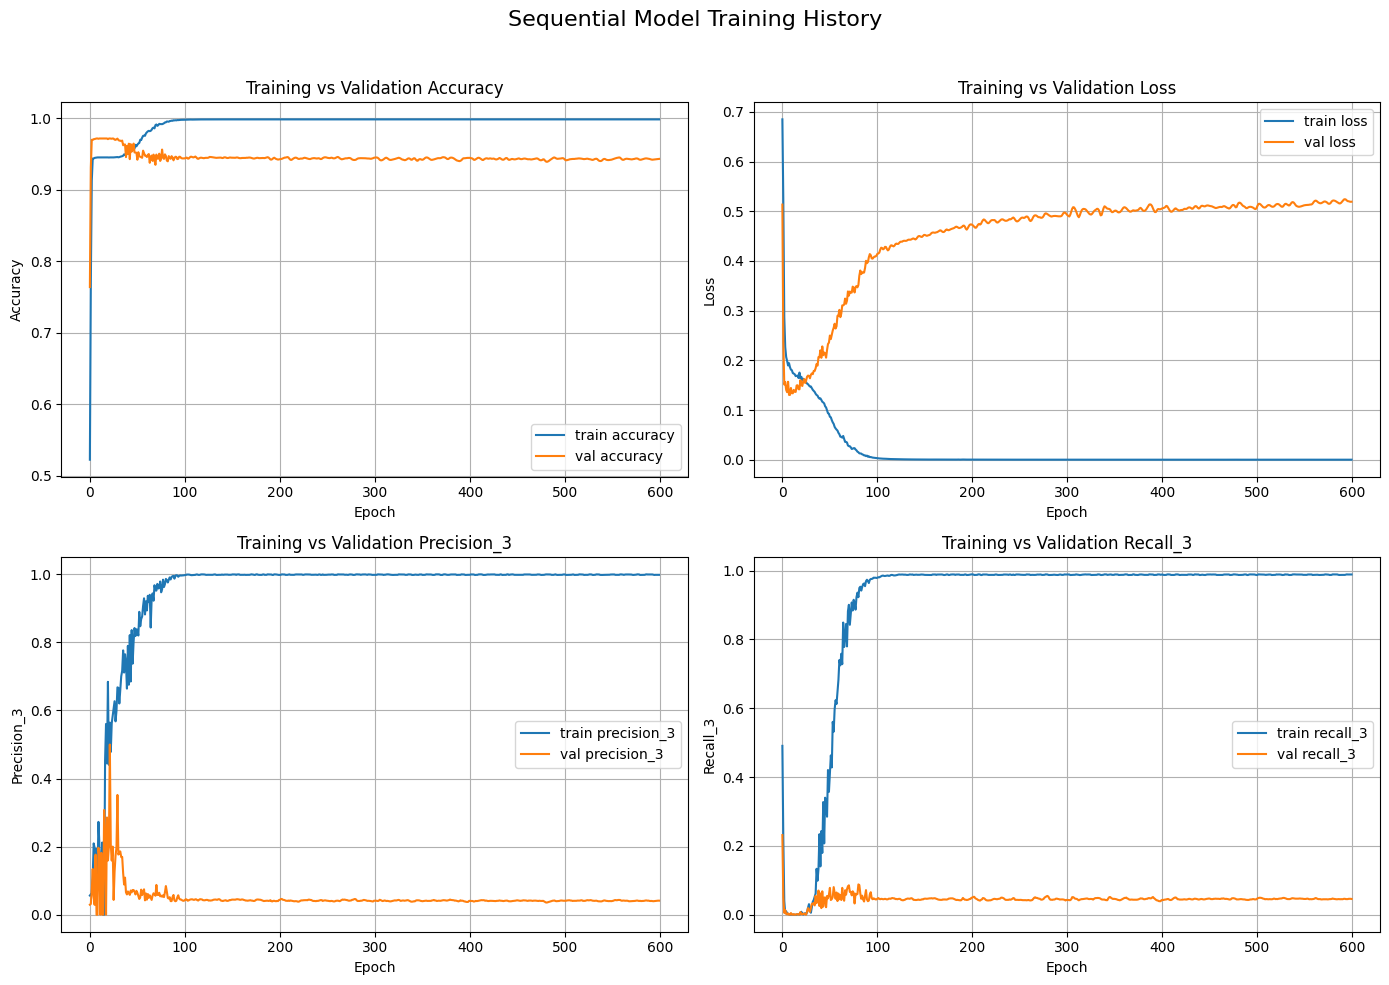

In [46]:
plot_training_history(sequential_history, title = "Sequential Model Training History")

In [47]:
seq_y_pred = sequential_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


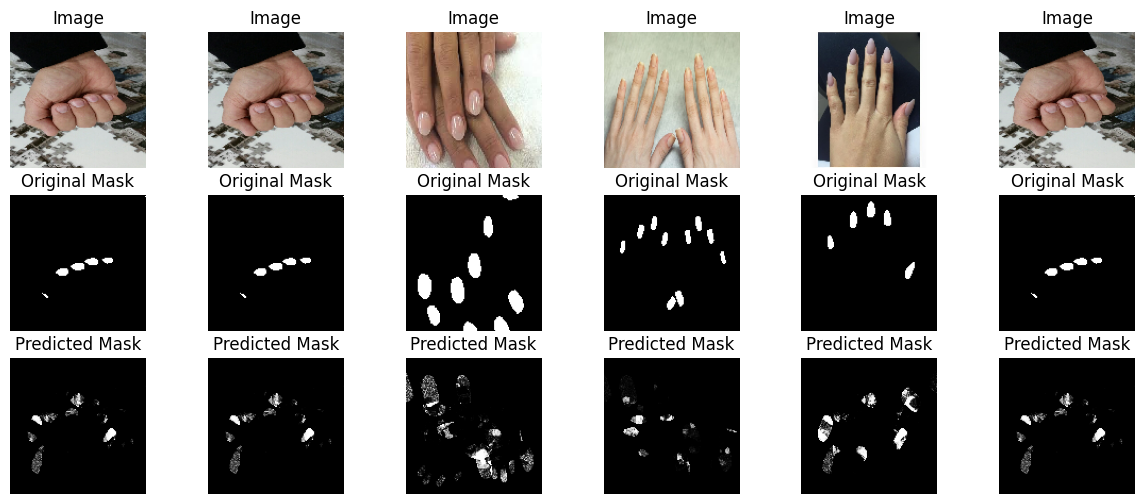

In [48]:
plot_predictions(X_test, y_test, seq_y_pred)

In [49]:
seq_results = sequential_model.evaluate(X_test, y_test, verbose=0)
metrics_names = sequential_model.metrics_names
for name, value in zip(metrics_names, seq_results):
    print(f"{name}: {value:.4f}")

loss: 0.5722
compile_metrics: 0.9357


### U-Net

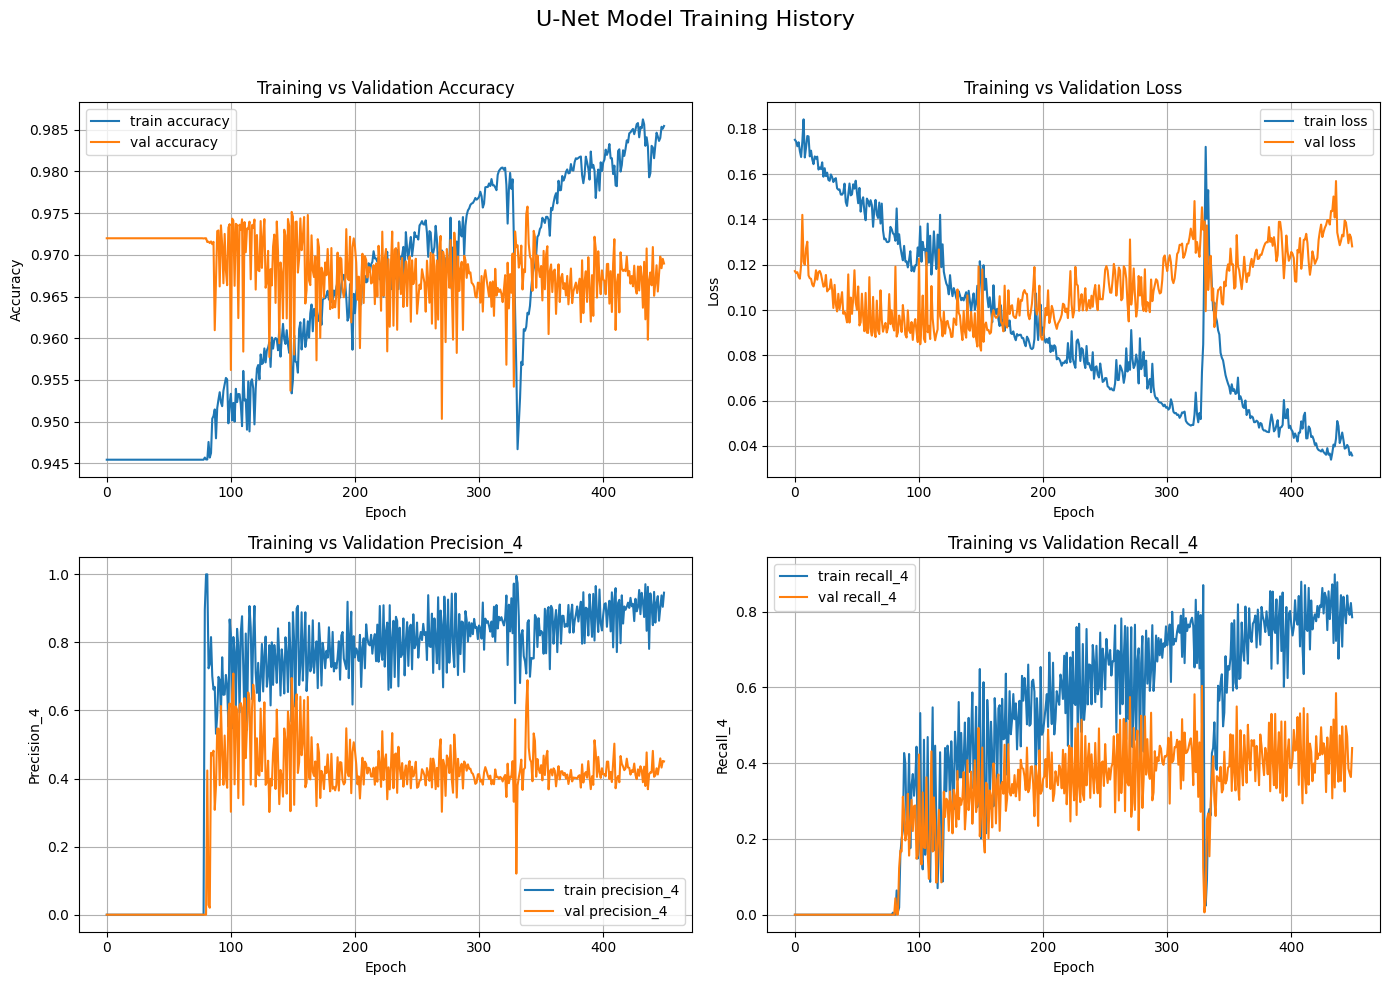

In [56]:
plot_training_history(unet_history, title = "U-Net Model Training History")

In [57]:
unet_y_pred = unet_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


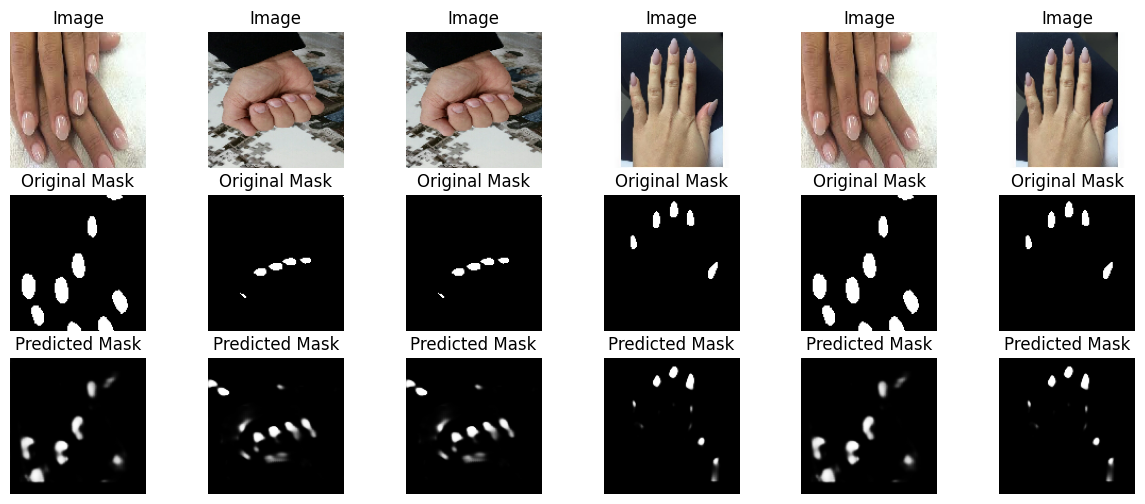

In [59]:
plot_predictions(X_test, y_test, unet_y_pred)

In [53]:
unet_results = unet_model.evaluate(X_test, y_test, verbose=0)
metrics_names = unet_model.metrics_names
for name, value in zip(metrics_names, unet_results):
    print(f"{name}: {value:.4f}")

loss: 0.1251
compile_metrics: 0.9670
